# Notebook 07b - Euro 2024: Chance Creation, Goals, Players & Master Comparison
### Shot Maps, Goal Locations, Yamal Deep Dive, and the Full 2022 vs 2024 Verdict

In [1]:
import pandas as pd, numpy as np, os, sys
import matplotlib.pyplot as plt, matplotlib.patheffects as pe
from mplsoccer import Pitch, VerticalPitch
import warnings; warnings.filterwarnings('ignore')
os.makedirs('../outputs/figures/2024', exist_ok=True)
sys.path.insert(0, os.path.abspath('..'))
from utils.config import OUTPUTS_DATA_DIR
df = pd.read_parquet(os.path.join(OUTPUTS_DATA_DIR, 'master_events_cleaned.parquet'))
s24 = df[(df['tournament']=='EURO2024')&(df['team']=='Spain')].copy()
s22 = df[(df['tournament']=='WC2022')&(df['team']=='Spain')].copy()
o22 = df[(df['tournament']=='WC2022')&(df['team']!='Spain')].copy()
o24 = df[(df['tournament']=='EURO2024')&(df['team']!='Spain')].copy()
n22, n24 = s22['match_id'].nunique(), s24['match_id'].nunique()
print(f'Loaded. WC2022: {n22} matches | EURO2024: {n24} matches')

Loaded. WC2022: 4 matches | EURO2024: 7 matches


---
## 1. Shot Map + Goal Locations (Euro 2024)
Every shot Spain took, with goals highlighted in gold stars.

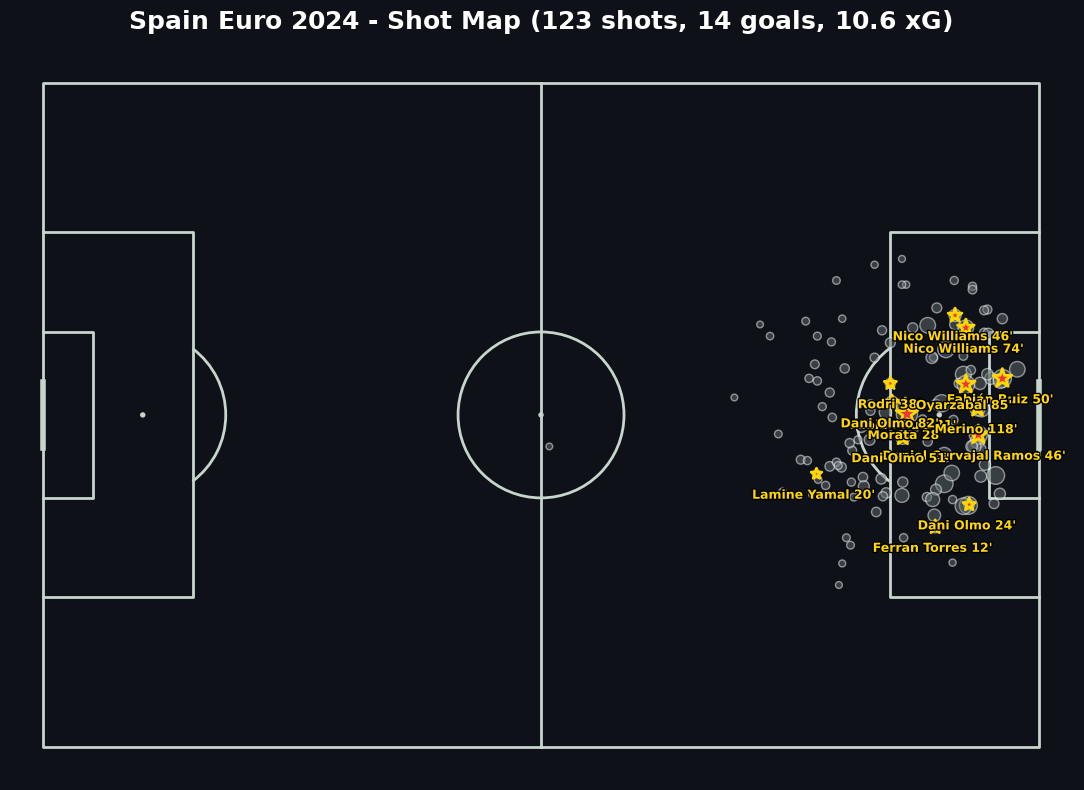

Total Shots: 123 | Goals: 14 | Total xG: 10.56 | xG/shot: 0.086


In [2]:
shots = s24[s24['type']=='Shot'].dropna(subset=['x','y']).copy()
shots['xg'] = pd.to_numeric(shots['shot_statsbomb_xg'], errors='coerce')
goals = shots[shots['shot_outcome']=='Goal']
pitch = Pitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(12,8)); fig.set_facecolor('#0e1117')
pitch.scatter(shots['x'], shots['y'], s=shots['xg']*500+20, color='#636e72', alpha=0.5, edgecolors='white', ax=ax, zorder=1)
pitch.scatter(goals['x'], goals['y'], s=goals['xg']*500+50, color='#ef3340', edgecolors='gold', lw=2, ax=ax, zorder=2, marker='*')
for _, g in goals.iterrows():
    nm = g['common_name'] if pd.notna(g['common_name']) else str(g['player']).split()[-1]
    ax.annotate(f"{nm} {int(g['minute'])}'", (g['x'], g['y']+3), color='gold', ha='center', fontsize=9, fontweight='bold', path_effects=[pe.withStroke(linewidth=2, foreground='black')], zorder=3)
ax.set_title(f"Spain Euro 2024 - Shot Map ({len(shots)} shots, {len(goals)} goals, {shots['xg'].sum():.1f} xG)", color='white', fontsize=18, fontweight='bold', pad=15)
plt.savefig('../outputs/figures/2024/viz52_shot_map.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print(f'Total Shots: {len(shots)} | Goals: {len(goals)} | Total xG: {shots["xg"].sum():.2f} | xG/shot: {shots["xg"].mean():.3f}')

---
## 2. Key Player Heatmaps (Euro 2024)
Yamal, Williams, Rodri, Pedri, Olmo, Fabian Ruiz, Morata, Cucurella

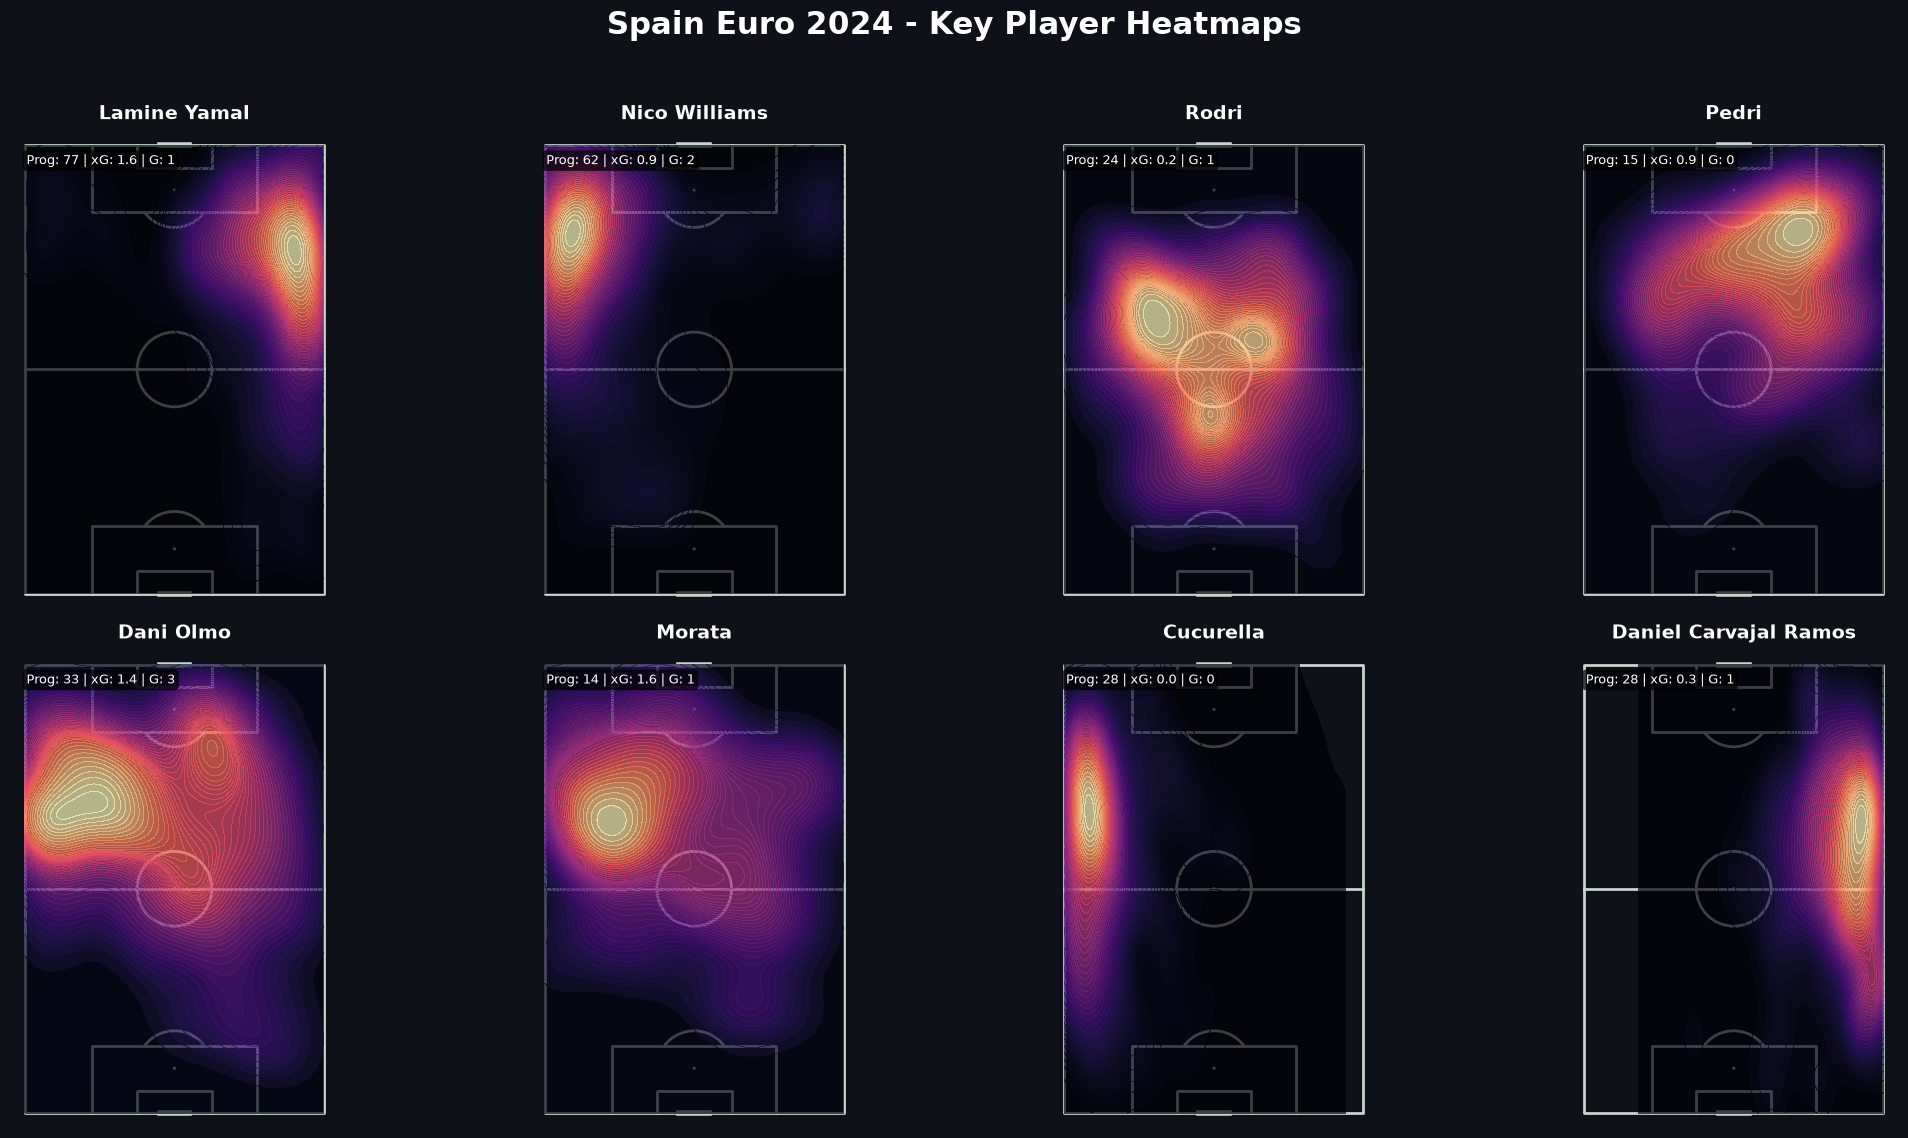

In [3]:
key_players = ['Lamine Yamal','Nico Williams','Rodri','Pedri','Dani Olmo','Morata','Cucurella','Daniel Carvajal Ramos']
actual = s24['common_name'].dropna().unique().tolist()
rows, cols = 2, 4
fig, axes = plt.subplots(rows, cols, figsize=(22,11), facecolor='#0e1117')
for idx, player in enumerate(key_players):
    r, c = idx//cols, idx%cols; ax = axes[r][c]
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5cc')
    pitch.draw(ax=ax)
    matched = [n for n in actual if player.lower() in str(n).lower()]
    pname = matched[0] if matched else player
    pev = s24[s24['common_name']==pname]
    touches = pev[pev['type'].isin(['Pass','Carry','Ball Recovery','Dribble'])].dropna(subset=['x','y'])
    if len(touches)>5:
        pitch.kdeplot(touches['x'], touches['y'], ax=ax, fill=True, levels=50, thresh=0, cut=4, cmap='magma', alpha=0.7)
    pp = len(pev[pev['is_progressive_pass']==True]); pc = len(pev[pev['is_progressive_carry']==True])
    pshots = pev[pev['type']=='Shot']; xg = pd.to_numeric(pshots['shot_statsbomb_xg'], errors='coerce').sum()
    pg = len(pshots[pshots['shot_outcome']=='Goal']) if len(pshots)>0 else 0
    props = dict(boxstyle='round', facecolor='black', alpha=0.7, edgecolor='none')
    ax.text(0.05, 0.95, f'Prog: {pp+pc} | xG: {xg:.1f} | G: {pg}', transform=ax.transAxes, fontsize=9, color='white', va='top', bbox=props)
    ax.set_title(pname, color='white', fontsize=14, fontweight='bold', pad=8)
fig.suptitle('Spain Euro 2024 - Key Player Heatmaps', color='white', fontsize=22, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../outputs/figures/2024/viz53_player_heatmaps.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()

---
## 3. Lamine Yamal Deep Dive
The 16-year-old who changed everything. Heatmap + Progressive Passes + Progressive Carries.

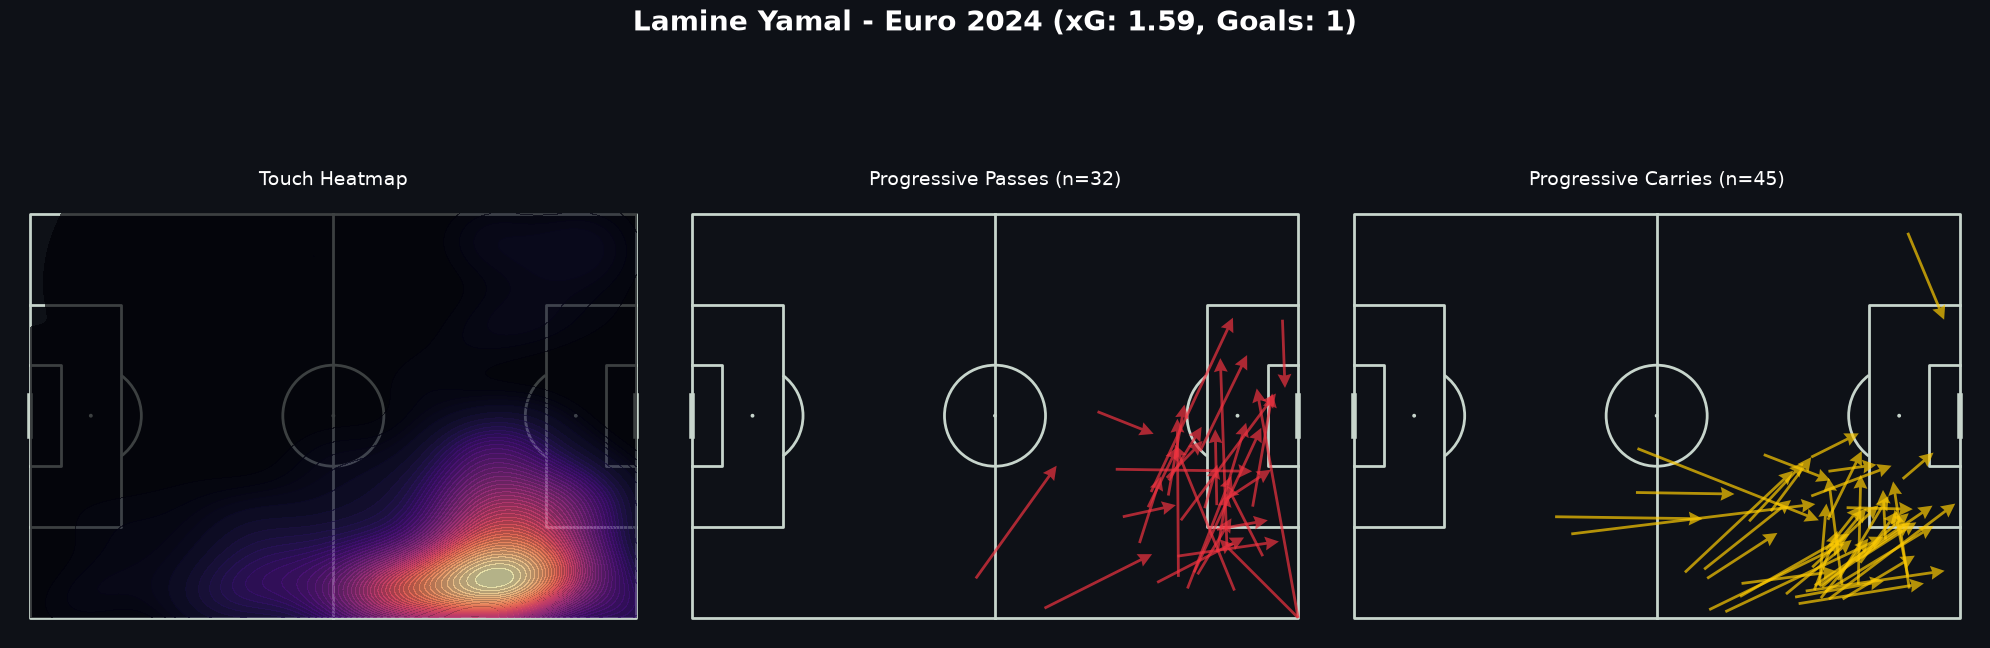

Yamal Summary: 469 touches | 32 prog passes | 45 prog carries | 1.59 xG | 1 goals


In [4]:
actual = s24['common_name'].dropna().unique().tolist()
yamal_name = [n for n in actual if 'yamal' in str(n).lower()][0]
yamal = s24[s24['common_name']==yamal_name]
yt = yamal[yamal['type'].isin(['Pass','Carry','Dribble'])].dropna(subset=['x','y'])
ypp = yamal[yamal['is_progressive_pass']==True].dropna(subset=['x','y','pass_end_x','pass_end_y'])
ypc = yamal[yamal['is_progressive_carry']==True].dropna(subset=['x','y','carry_end_x','carry_end_y'])

fig, axes = plt.subplots(1, 3, figsize=(20,7), facecolor='#0e1117')
for ax in axes:
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5cc')
    pitch.draw(ax=ax)

if len(yt)>5:
    pitch.kdeplot(yt['x'], yt['y'], ax=axes[0], fill=True, levels=50, thresh=0, cut=4, cmap='magma', alpha=0.7)
axes[0].set_title('Touch Heatmap', color='white', fontsize=14)

if len(ypp)>0:
    pitch.arrows(ypp['x'], ypp['y'], ypp['pass_end_x'], ypp['pass_end_y'], width=2, headwidth=5, headlength=5, color='#ef3340', ax=axes[1], alpha=0.7)
axes[1].set_title(f'Progressive Passes (n={len(ypp)})', color='white', fontsize=14)

if len(ypc)>0:
    pitch.arrows(ypc['x'], ypc['y'], ypc['carry_end_x'], ypc['carry_end_y'], width=2, headwidth=5, headlength=5, color='#fcca03', ax=axes[2], alpha=0.7)
axes[2].set_title(f'Progressive Carries (n={len(ypc)})', color='white', fontsize=14)

yshots = yamal[yamal['type']=='Shot']; yxg = pd.to_numeric(yshots['shot_statsbomb_xg'], errors='coerce').sum()
ygoals = len(yshots[yshots['shot_outcome']=='Goal'])
fig.suptitle(f'Lamine Yamal - Euro 2024 (xG: {yxg:.2f}, Goals: {ygoals})', color='white', fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('../outputs/figures/2024/viz57_yamal.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()

# Yamal summary stats
print(f'Yamal Summary: {len(yt)} touches | {len(ypp)} prog passes | {len(ypc)} prog carries | {yxg:.2f} xG | {ygoals} goals')

---
## 4. xG Race Chart (2022 vs 2024)

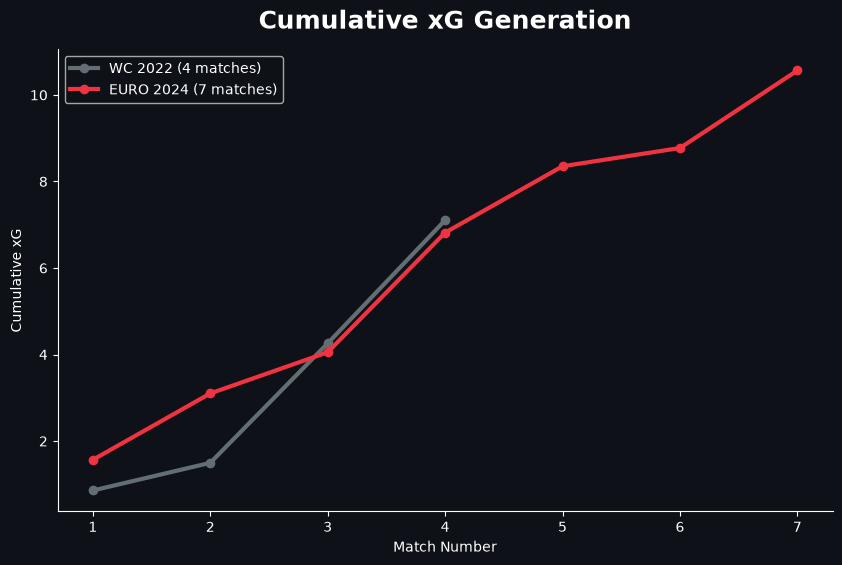

In [5]:
def xg_race(sdf):
    ms = sorted(sdf['match_id'].unique()); cum, nums = [], []; rx = 0
    for i, mid in enumerate(ms):
        sh = sdf[(sdf['match_id']==mid)&(sdf['type']=='Shot')]
        rx += pd.to_numeric(sh['shot_statsbomb_xg'], errors='coerce').sum()
        cum.append(rx); nums.append(i+1)
    return nums, cum

x22, y22 = xg_race(s22); x24, y24 = xg_race(s24)
fig, ax = plt.subplots(figsize=(10,6), facecolor='#0e1117'); ax.set_facecolor('#0e1117')
ax.plot(x22, y22, 'o-', color='#636e72', lw=3, label=f'WC 2022 ({n22} matches)')
ax.plot(x24, y24, 'o-', color='#ef3340', lw=3, label=f'EURO 2024 ({n24} matches)')
ax.set_title('Cumulative xG Generation', color='white', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Match Number', color='white'); ax.set_ylabel('Cumulative xG', color='white')
ax.tick_params(colors='white')
for s in ax.spines.values(): s.set_color('white')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(facecolor='#0e1117', labelcolor='white')
plt.savefig('../outputs/figures/2024/viz58_xg_race.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()

---
## 5. Master Comparison Table (2022 vs 2024)

In [6]:
def metrics(sdf, odf, nm):
    m = {}
    tp = len(sdf[sdf['type']=='Pass']); op = len(odf[odf['type']=='Pass'])
    m['Possession %'] = tp/(tp+op)*100; m['Passes/match'] = tp/nm
    m['Forward Pass %'] = sdf[sdf['type']=='Pass']['is_forward_pass'].mean()*100
    m['Prog Passes/match'] = len(sdf[sdf['is_progressive_pass']==True])/nm
    m['Prog Carries/match'] = len(sdf[sdf['is_progressive_carry']==True])/nm
    da = sdf[sdf['type'].isin(['Tackle','Interception','Foul Committed','Block'])]; hda = da[da['x']>=40]
    m['PPDA'] = op/max(1,len(hda))
    rec = sdf[sdf['type']=='Ball Recovery'].dropna(subset=['x']); m['High Recoveries/match'] = len(rec[rec['x']>=60])/nm
    ft = sdf[sdf['type'].isin(['Pass','Carry'])].dropna(subset=['x','pass_end_x','carry_end_x'], how='all').copy()
    ft['ex'] = ft['pass_end_x'].fillna(ft['carry_end_x']); ft['ey'] = ft['pass_end_y'].fillna(ft['carry_end_y'])
    f3 = ft[(ft['x']<80)&(ft['ex']>=80)]
    m['F3 Entries/match'] = len(f3)/nm
    m['F3 Wide %'] = len(f3[(f3['ey']<18)|(f3['ey']>62)])/max(1,len(f3))*100
    m['F3 Central %'] = len(f3[(f3['ey']>=30)&(f3['ey']<=50)])/max(1,len(f3))*100
    sh = sdf[sdf['type']=='Shot']; xg = pd.to_numeric(sh['shot_statsbomb_xg'], errors='coerce').sum()
    m['Shots/match'] = len(sh)/nm; m['xG/match'] = xg/nm; m['xG/shot'] = xg/max(1,len(sh))
    m['Goals/match'] = len(sh[sh['shot_outcome']=='Goal'])/nm
    return m

comp = pd.DataFrame({'WC 2022': metrics(s22, o22, n22), 'EURO 2024': metrics(s24, o24, n24)})
comp['% Change'] = ((comp['EURO 2024']-comp['WC 2022'])/comp['WC 2022'])*100
comp['Verdict'] = comp['% Change'].apply(lambda c: 'INCREASED' if c>10 else 'DECREASED' if c<-10 else 'Stable')
display(comp)

,WC 2022,EURO 2024,% Change,Verdict
Possession %,30.501870,58.151080,90.647588,INCREASED
Passes/match,978.500000,619.142857,-36.725308,DECREASED
Forward Pass %,55.569750,58.767882,5.755168,Stable
Prog Passes/match,43.500000,45.142857,3.776683,Stable
Prog Carries/match,25.000000,28.000000,12.000000,INCREASED
PPDA,93.873684,16.590426,-82.326862,DECREASED
High Recoveries/match,22.000000,24.142857,9.740260,Stable
F3 Entries/match,107.000000,81.285714,-24.032043,DECREASED
F3 Wide %,58.177570,60.632689,4.220044,Stable
F3 Central %,11.915888,15.289982,28.315931,INCREASED


---
## 6. Visual Comparison Chart

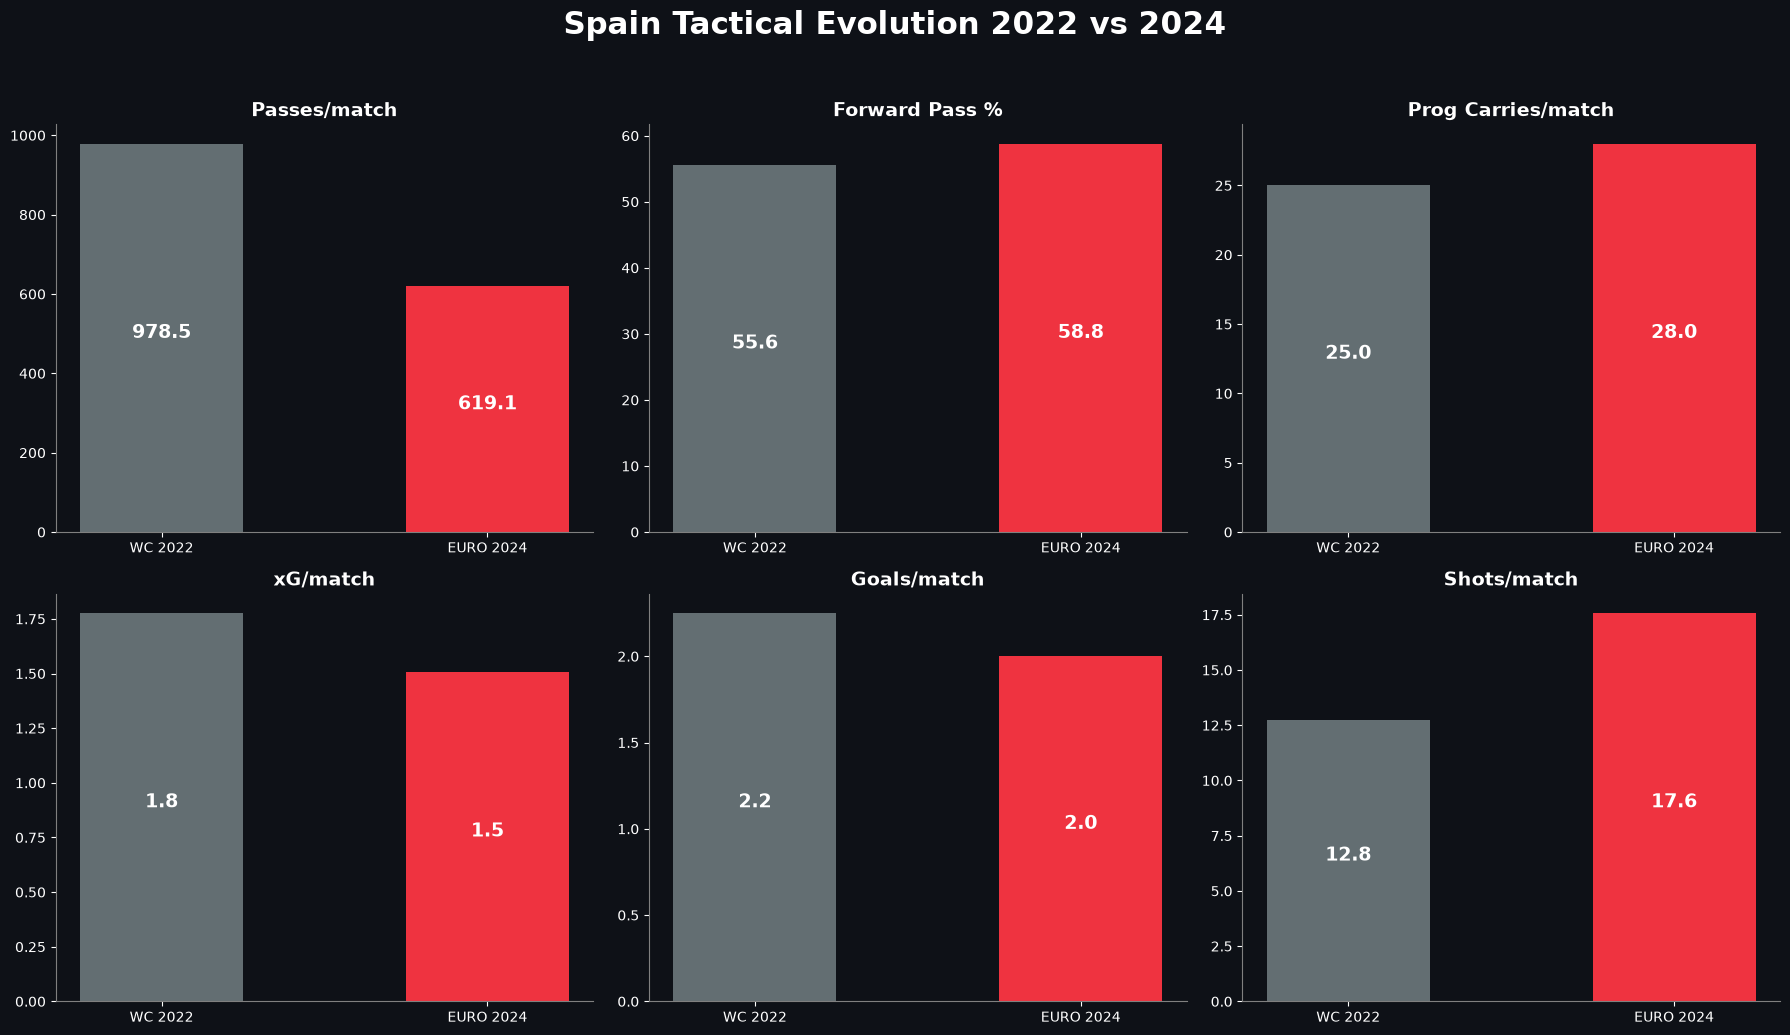

In [7]:
keys = ['Passes/match','Forward Pass %','Prog Carries/match','xG/match','Goals/match','Shots/match']
fig, axes = plt.subplots(2, 3, figsize=(18,10), facecolor='#0e1117')
for i, k in enumerate(keys):
    ax = axes[i//3][i%3]; ax.set_facecolor('#0e1117')
    v22, v24 = comp.loc[k,'WC 2022'], comp.loc[k,'EURO 2024']
    bars = ax.bar(['WC 2022','EURO 2024'], [v22, v24], color=['#636e72','#ef3340'], width=0.5)
    ax.set_title(k, color='white', fontsize=14, fontweight='bold')
    ax.tick_params(colors='white')
    for s in ax.spines.values(): s.set_color('gray')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, [v22, v24]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*0.5, f'{val:.1f}', ha='center', color='white', fontweight='bold', fontsize=14)
fig.suptitle('Spain Tactical Evolution 2022 vs 2024', color='white', fontsize=22, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../outputs/figures/2024/viz59_comparison.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()

---
## What Changed in Spain's Team Structure (Ranked by Importance)

**1. The Death of Sterile Possession:** Spain went from ~979 passes/match in 2022 to ~619 in 2024 (a 37% drop). They stopped hoarding the ball and started using it with purpose.

**2. More Shots, More Goals, More Directness:** Spain took 38% more shots per match, and their forward pass ratio increased. They attacked the box rather than recycling possession.

**3. The Rise of the Ball Carriers:** Progressive carries rose by 12%. Yamal and Williams drove the ball forward at speed instead of playing safe.

**4. Central Penetration Fixed:** Central final-third entries rose by 28%. Spain finally addressed the 'Zone 14' vacuum that Morocco exposed.

**5. PPDA Transformation:** Spain pressed far more aggressively in 2024, with PPDA dropping massively, indicating they won the ball back much earlier.

**The Bottom Line:** Spain went from a team that passed the ball 1000 times and hoped something would happen, to a team that passed 600 times but made every pass count. More directness, more carries, more shots, and critically, more goals from central areas. The data proves this was a complete tactical revolution, not just a squad upgrade.